Este Bloque sirve para ver el contenido/Estructura del dataset

In [1]:
import os

BASE = "/kaggle/input"
# Lista qué carpetas montó Kaggle (el nombre exacto varía)
for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, "").count(os.sep)
    if depth <= 3:
        print("  " * depth + os.path.basename(root) + "/")

input/
  datasets/
    snehilsanyal/
      construction-site-safety-image-dataset-roboflow/


In [5]:
import os

BASE = "/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow"

for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, "").count(os.sep)
    print("  " * depth + os.path.basename(root) + "/")
    if depth < 4:
        for f in files[:5]:  # muestra máximo 5 archivos por carpeta
            print("  " * (depth + 1) + f)
    if depth >= 4:
        dirs.clear()

construction-site-safety-image-dataset-roboflow/
  css-data/
    README.dataset.txt
    README.roboflow.txt
    valid/
      labels/
        construction-3-_mp4-219_jpg.rf.416dbf917b54d5895e2430fa0d6f1b66.txt
        construction-1-_mp4-147_jpg.rf.a9062a80b06ac796f7afb269e5f18c53.txt
        Movie-on-10-31-22-at-10_08-AM_mov-13_jpg.rf.91dc3b79da617fb2e4321f27f48f21f4.txt
        2009_002778_jpg.rf.7c8977ed190a2ce4211ef58f66864066.txt
        004424_jpg.rf.0470713b945b08839105cde711db62d9.txt
      images/
        IMG_3094_mp4-3_jpg.rf.65429c37fcf92b2ba8cfc9d2180051ef.jpg
        youtube-70_jpg.rf.2d5f69c78f062dfc572ccb6ce6bc3c9b.jpg
        youtube-51_jpg.rf.083f4487f9a468d9ff42aa13953f377a.jpg
        -1969-_png_jpg.rf.41dd58ed3ae83df95fb2417c679d581f.jpg
        youtube-232_jpg.rf.f92f310106a11e01495ce8bfae0f9b5a.jpg
    test/
      labels/
        youtube-631_jpg.rf.7c6ecf859c1b0a659f8ea057ad27aebd.txt
        Image36_jpg.rf.8704f3450f736cdd01a61dcee588f2c2.txt
        IMG_0871_MOV-

Conteo de clases

In [6]:
import yaml, glob, os

BASE = "/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow"
DATA_DIR = f"{BASE}/css-data"

yaml_path = glob.glob(f"{BASE}/**/ppe_data.yaml", recursive=True)[0]
with open(yaml_path) as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]
print("Clases:", CLASSES)
print("Total de clases:", len(CLASSES))

Clases: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
Total de clases: 10


conteo de imágenes y anotaciones por clase

In [7]:
from collections import Counter

def contar(split):
    labels = glob.glob(f"{DATA_DIR}/{split}/labels/*.txt")
    imgs = glob.glob(f"{DATA_DIR}/{split}/images/*")
    conteo = Counter()
    for lf in labels:
        with open(lf) as f:
            for line in f:
                if line.strip():
                    conteo[int(line.split()[0])] += 1
    return len(imgs), conteo

resultados = {s: contar(s) for s in ["train", "valid", "test"]}

print(f"{'Clase':<18}{'train':>8}{'valid':>8}{'test':>8}")
for i, nombre in enumerate(CLASSES):
    fila = "".join(f"{resultados[s][1].get(i, 0):>8}" for s in resultados)
    print(f"{nombre:<18}{fila}")

print("\nImágenes por split:", {s: r[0] for s, r in resultados.items()})

Clase                train   valid    test
Hardhat               3145      79     110
Mask                  1651      21      28
NO-Hardhat            2317      69      41
NO-Mask               3097      74      79
NO-Safety Vest        3962     106      90
Person                9532     166     174
Safety Cone           3366      44      92
Safety Vest           3033      41      61
machinery             5247      55      44
vehicle               1545      42      41

Imágenes por split: {'train': 2605, 'valid': 114, 'test': 82}


visualización de imágenes con sus cajas

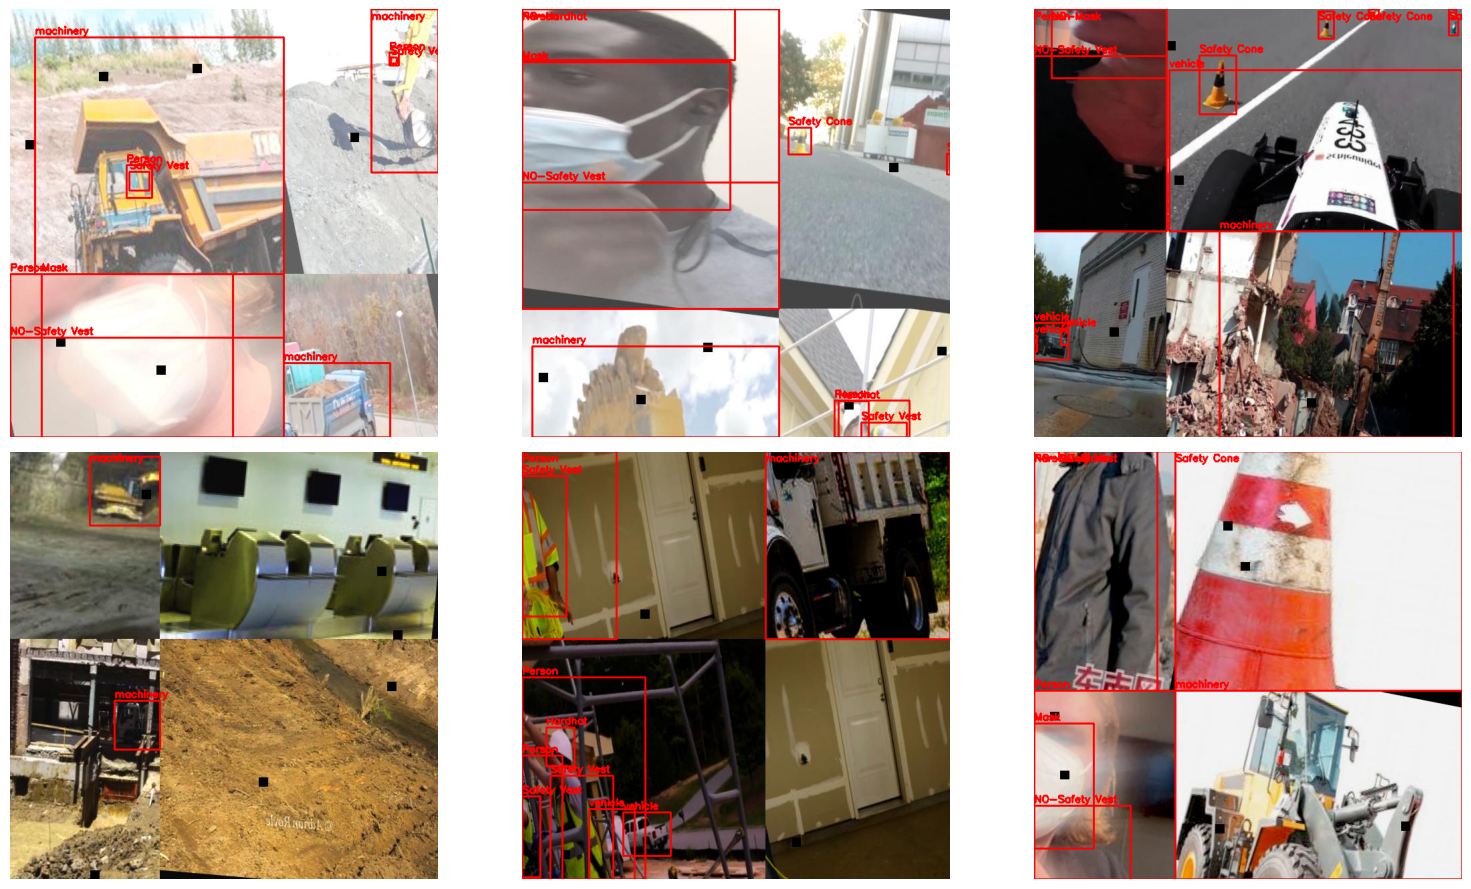

In [8]:
import cv2, random
import matplotlib.pyplot as plt

def dibujar(img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    if os.path.exists(label):
        with open(label) as f:
            for line in f:
                c, x, y, bw, bh = line.split()[:5]
                x, y, bw, bh = float(x)*w, float(y)*h, float(bw)*w, float(bh)*h
                p1 = (int(x-bw/2), int(y-bh/2)); p2 = (int(x+bw/2), int(y+bh/2))
                cv2.rectangle(img, p1, p2, (255, 0, 0), 2)
                cv2.putText(img, CLASSES[int(c)], (p1[0], max(p1[1]-5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img

muestras = random.sample(glob.glob(f"{DATA_DIR}/train/images/*"), 6)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, p in zip(axes.flat, muestras):
    ax.imshow(dibujar(p)); ax.axis("off")
plt.tight_layout(); plt.show()